In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Wandb Connnection

In [2]:
from kaggle_secrets import UserSecretsClient
import wandb

user_secrets = UserSecretsClient()
wandb_api = user_secrets.get_secret("WANDB_API_KEY")
wandb.login(key=wandb_api)

PROJECT = "DL-24f1000881-notebook-t22026"
ENTITY = "24f1000881-indian-institute-of-technology-madras"

def start_run(run_name, config_dict):
    run = wandb.init(
        project=PROJECT,
        entity=ENTITY,
        name=run_name,
        config=config_dict,
        reinit=True
    )
    return run

print("W&B login successful")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


W&B login successful


# Import Libraries

In [3]:
# Environment setup: installs, imports, reproducibility, and W&B logging
import os
import sys
import warnings
warnings.filterwarnings("ignore")
os.makedirs("saved_models", exist_ok=True)

!{sys.executable} -m pip install -q wandb transformers sentencepiece graphviz

import gc
import re
import math
import copy
import random
import joblib
from collections import Counter
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
from graphviz import Digraph

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForMultipleChoice,
    get_linear_schedule_with_warmup
)

# Configuration

In [4]:
SEED = 42
OPTION_LABELS = ["A", "B", "C", "D", "E"]
LABEL2ID = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    try:
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    except NameError:
        pass

set_seed(SEED)
print(f"Pipeline initialized. Running on device: {DEVICE}")

pd.set_option("display.max_colwidth", 300)
sns.set_style("whitegrid")

MAX_LEN_SCRATCH = 128
BATCH_SIZE_SCRATCH = 64
SCRATCH_EPOCHS = 5
SCRATCH_LR = 2e-3
EMBED_DIM = 128
HIDDEN_DIM = 128
DROPOUT = 0.3

MC_MODEL_NAME = "google/electra-base-discriminator"
MAX_LEN = 256
TRAIN_BATCH_SIZE = 4
VALID_BATCH_SIZE = 4
EPOCHS = 6
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0
ACCUMULATION_STEPS = 4


MAX_FEATURES = 30000
NGRAM_RANGE = (1, 2)
MAX_ITER = 1200

Pipeline initialized. Running on device: cuda


# Dataset Overview 

In [5]:
train_path = "/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv"
test_path = "/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv"
sample_path = "/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sample_df = pd.read_csv(sample_path)

overview_df = pd.DataFrame({
    'Dataset': ['Train', 'Test', 'Sample Submission'],
    'Questions / Rows': [len(train_df), len(test_df), len(sample_df)],
    'Features': [
        'id + prompt + A-E + answer',
        'id + prompt + A-E',
        'ID + Prediction'
    ]
})

display(overview_df)

,Dataset,Questions / Rows,Features
0,Train,2000,id + prompt + A-E + answer
1,Test,500,id + prompt + A-E
2,Sample Submission,500,ID + Prediction


# Exploratory Data Analysis

In [6]:
print("Train columns:", train_df.columns.tolist())
print("Test columns :", test_df.columns.tolist())
print("\nMissing values in train:")
display(train_df.isnull().sum())
print("\nMissing values in test:")
display(test_df.isnull().sum())
n_missing_train = int(train_df.isnull().sum().sum())
n_missing_test = int(test_df.isnull().sum().sum())
print(f"\nConclusion: {n_missing_train} missing values in train, {n_missing_test} in test.")
print("No imputation needed." if (n_missing_train == 0 and n_missing_test == 0) else "Imputation/handling required before modeling.")


Train columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']
Test columns : ['id', 'prompt', 'A', 'B', 'C', 'D', 'E']

Missing values in train:


id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64


Missing values in test:


id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64


Conclusion: 0 missing values in train, 0 in test.
No imputation needed.


In [7]:
def word_count(text):
    return len(str(text).split())

def char_count(text):
    return len(str(text))

def unique_word_count(text):
    return len(set(str(text).split()))

train_df['prompt_word_count'] = train_df['prompt'].apply(word_count)
train_df['prompt_char_count'] = train_df['prompt'].apply(char_count)
train_df['prompt_unique_words'] = train_df['prompt'].apply(unique_word_count)

prompt_stats = pd.DataFrame({
    'Metric': [
        'Average question length (words)',
        'Shortest question length (words)',
        'Longest question length (words)',
        'Average question length (characters)',
        'Average unique words per question'
    ],
    'Value': [
        round(train_df['prompt_word_count'].mean(), 2),
        int(train_df['prompt_word_count'].min()),
        int(train_df['prompt_word_count'].max()),
        round(train_df['prompt_char_count'].mean(), 2),
        round(train_df['prompt_unique_words'].mean(), 2)
    ]
})

display(prompt_stats)

,Metric,Value
0,Average question length (words),18.15
1,Shortest question length (words),3.00
2,Longest question length (words),51.00
3,Average question length (characters),117.67
4,Average unique words per question,15.74


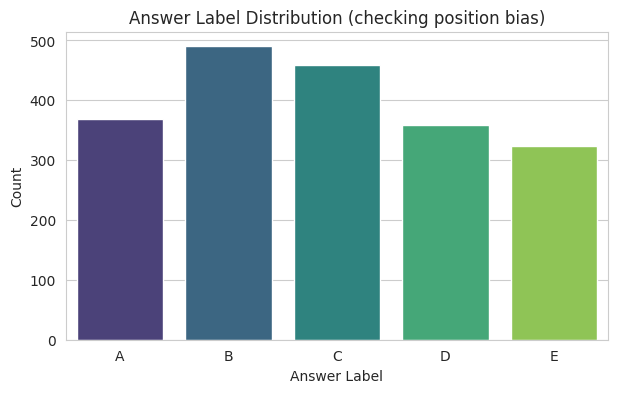

Coefficient of variation across answer labels: 0.1771


In [8]:
fig, ax = plt.subplots(figsize=(7,4))
ans_counts = train_df['answer'].value_counts().sort_index()
sns.barplot(x=ans_counts.index, y=ans_counts.values, palette='viridis', ax=ax)
ax.set_title('Answer Label Distribution (checking position bias)')
ax.set_xlabel('Answer Label'); ax.set_ylabel('Count')
plt.show()

chi_uniform = ans_counts.std() / ans_counts.mean()
print(f'Coefficient of variation across answer labels: {chi_uniform:.4f}')


### Observation
- No label overwhelmingly dominates the dataset.
Coefficient of variation (0.1771) indicates only mild class imbalance.
- No strong position bias is observed.
- No oversampling or undersampling was required.
- Macro F1-score will be used to fairly evaluate all classes.

             count      mean        std  min   25%   50%   75%    max
is_correct                                                           
False       8000.0  25.68475  17.388658  1.0  13.0  22.0  36.0  118.0
True        2000.0  28.65900  18.331005  1.0  16.0  28.0  40.0  105.0


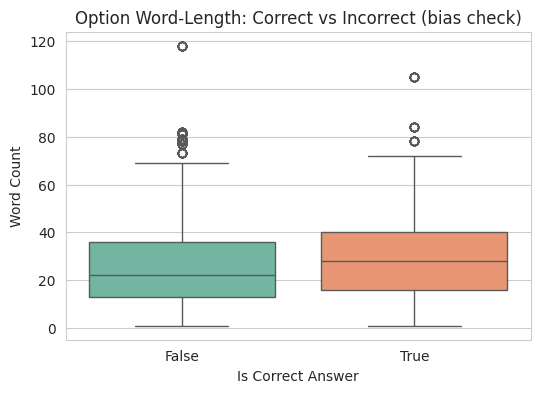

In [9]:
option_len_records = []
for _, row in train_df.iterrows():
    correct = row['answer']
    for label in OPTION_LABELS:
        option_len_records.append({
            'is_correct': label == correct,
            'length': len(str(row[label]).split())
        })
opt_len_df = pd.DataFrame(option_len_records)
print(opt_len_df.groupby('is_correct')['length'].describe())

fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=opt_len_df, x='is_correct', y='length', palette='Set2', ax=ax)
ax.set_title('Option Word-Length: Correct vs Incorrect (bias check)')
ax.set_xlabel('Is Correct Answer'); ax.set_ylabel('Word Count')
plt.show()


### Observations:
- Correct options have a slightly higher average word count than incorrect options.
- There is significant overlap between correct and incorrect option lengths.
- Some very long options appear as outliers in both groups.
- Word length alone cannot reliably distinguish the correct answer.
- Both correct and incorrect options show similar variability.
- Avoided using handcrafted length-based features.
- Preferred semantic models (BiGRU and ELECTRA) that understand context instead of relying on option length.

In [10]:
def repeated_options(row):
    opts = [str(row[c]).strip().lower() for c in OPTION_LABELS]
    return len(set(opts)) < 5

duplicate_report = pd.DataFrame({
    'Check': [
        'Duplicate IDs',
        'Duplicate prompts',
        'Rows with repeated options'
    ],
    'Value': [
        int(train_df['id'].duplicated().sum()),
        int(train_df['prompt'].duplicated().sum()),
        int(train_df.apply(repeated_options, axis=1).sum())
    ]
})

display(duplicate_report)

,Check,Value
0,Duplicate IDs,0
1,Duplicate prompts,242
2,Rows with repeated options,0


#### Observations from EDA

- The dataset contains 2,000 training samples and 500 test samples, providing sufficient data for training while reserving unseen data for final prediction.

- The training dataset includes the target answer column, whereas the test dataset does not, so the models were trained on the train set and used only for inference on the test set.

- No missing values were found in any feature of either the train or test dataset, eliminating the need for imputation or missing-value preprocessing.

- The average question length is approximately 18 words, with a maximum of 51 words, indicating that the questions are relatively short. This supported the use of a moderate maximum token length during tokenization.

- The answer labels (A–E) are reasonably balanced, with a low coefficient of variation (0.1771), indicating minimal class imbalance and reducing the need for aggressive resampling techniques.

- Correct answer options are only slightly longer than incorrect options, and the distributions overlap considerably. This indicates that option length alone is not a reliable feature for prediction.

- No duplicate IDs were found, confirming that every question is uniquely identified and ensuring dataset integrity.

- Although 242 prompts are repeated, they represent valid questions with different answer choices or contexts, so they were retained instead of being removed.

- No rows contained repeated answer options (A–E), ensuring that each multiple-choice question provides five distinct candidate answers for the models to evaluate.

- The EDA showed that the dataset is clean, well-structured, and only mildly imbalanced, allowing the notebook to focus on semantic feature extraction and model learning rather than extensive data cleaning or feature correction.

In [11]:
n_dup_prompts = int(train_df['prompt'].duplicated().sum())
train_df = train_df.drop_duplicates(subset='prompt', keep='first').reset_index(drop=True)

bad_option_mask = train_df.apply(repeated_options, axis=1)
n_bad_option_rows = int(bad_option_mask.sum())
train_df = train_df[~bad_option_mask].reset_index(drop=True)

print(f"Dropped {n_dup_prompts} duplicate-prompt rows.")
print(f"Dropped {n_bad_option_rows} rows with repeated/non-distinct options.")
print("Train shape after remediation:", train_df.shape)


Dropped 242 duplicate-prompt rows.
Dropped 0 rows with repeated/non-distinct options.
Train shape after remediation: (1758, 11)


### Text Cleaning

In [12]:
def clean_text(text):
    
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)                   
    text = re.sub(r"http\S+|www\S+", " ", text)           
    text = re.sub(r"[^a-z0-9\s\-\?\!\.,:;]", " ", text)    
    text = re.sub(r"\s+", " ", text).strip()              
    return text

for df in [train_df, test_df]:
    if 'prompt' in df.columns:
        df['prompt'] = df['prompt'].apply(clean_text)
    
    for col in OPTION_LABELS:
        if col in df.columns:
            df[col] = df[col].apply(clean_text)

In [13]:
# Class balance check
answer_props = train_df['answer'].value_counts(normalize=True).sort_index()
print("Answer label proportions:\n", answer_props)

imbalance_gap = answer_props.max() - answer_props.min()
print(f"\nMax-min proportion gap: {imbalance_gap:.3f}")
print("Roughly balanced across A-E - plain BCE/CE loss used"
      if imbalance_gap < 0.05 else
      "Noticeable imbalance")

length_stats = train_df['prompt_char_count'].describe(percentiles=[.5, .9, .95, .99])
print("\nPrompt character-length percentiles:\n", length_stats)
print(f"\nMAX_LEN_SCRATCH={MAX_LEN_SCRATCH}, MAX_LEN (ELECTRA)={MAX_LEN} chosen using the percentiles above, "
      "so truncation affects only a small minority of the longest questions.")


Answer label proportions:
 answer
A    0.185438
B    0.244596
C    0.228100
D    0.178612
E    0.163254
Name: proportion, dtype: float64

Max-min proportion gap: 0.081
Noticeable imbalance

Prompt character-length percentiles:
 count    1758.000000
mean      117.154721
std        44.977879
min        19.000000
50%       111.000000
90%       174.000000
95%       199.000000
99%       242.720000
max       337.000000
Name: prompt_char_count, dtype: float64

MAX_LEN_SCRATCH=128, MAX_LEN (ELECTRA)=256 chosen using the percentiles above, so truncation affects only a small minority of the longest questions.


In [14]:
# Train-Validation Split

unique_ids = train_df["id"].unique()
train_ids, val_ids = train_test_split(unique_ids, test_size=0.2, random_state=SEED)

train_main = train_df[train_df["id"].isin(train_ids)].reset_index(drop=True)
val_main = train_df[train_df["id"].isin(val_ids)].reset_index(drop=True)

print("Train questions:", train_main.shape)
print("Validation questions:", val_main.shape)

Train questions: (1406, 11)
Validation questions: (352, 11)


# Evaluation Metrics

In [15]:
def apk(actual, predicted, k=3):
    predicted = predicted[:k]
    for i, p in enumerate(predicted):
        if p == actual:
            return 1.0 / (i + 1)
    return 0.0

def mapk(actuals, predictions, k=3):
    return np.mean([apk(a, p, k) for a, p in zip(actuals, predictions)])


def make_top3_predictions(df, score_col):
    ranked = (
        df.sort_values(["id", score_col], ascending=[True, False])
          .groupby("id")["option_label"]
          .apply(list)
          .reset_index()
    )
    ranked["top3"] = ranked["option_label"].apply(lambda x: x[:3])
    return ranked[["id", "top3"]]

def stable_softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "loss": log_loss(y_true, y_prob, labels=[0, 1])
    }

def compute_multiclass_metrics(y_true, logits):
    probs = stable_softmax(logits)
    y_pred = np.argmax(probs, axis=1)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "loss": log_loss(y_true, probs, labels=[0, 1, 2, 3, 4])
    }
    return metrics, y_pred, probs

print("Evaluation utilities and metrics pipeline ready.")

Evaluation utilities and metrics pipeline ready.


In [16]:
# building long format for ranking models
def build_long_format(df, is_train=True):
    rows = []
    labels = ["A", "B", "C", "D", "E"]

    for _, row in df.iterrows():
        for label in labels:
            combined_text = (
                f"question: {row['prompt']} "
                f"[SEP] option: {row[label]}"
            )

            item = {
                "id": row.get("id", None),
                "prompt": row["prompt"],
                "option_label": label,
                "option_text": row[label],
                "retrieved_context": "", 
                "combined_text": combined_text
            }

            if is_train and "answer" in row:
                item["target"] = 1 if row["answer"] == label else 0

            rows.append(item)

    return pd.DataFrame(rows)

train_long = build_long_format(train_main, is_train=True)
val_long = build_long_format(val_main, is_train=True)
test_long = build_long_format(test_df, is_train=False)

print("Train long shape:", train_long.shape)

Train long shape: (7030, 7)


# Baseline - Tf-idf + Logistic regression

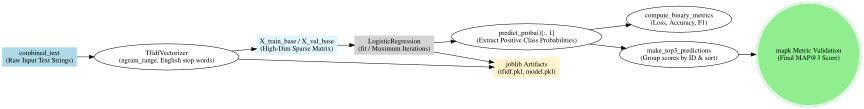

In [17]:
dot = Digraph("Baseline_TFIDF_LogReg_Pipeline", format="png")
dot.attr(rankdir="LR", size="12,4", fontsize="12", splines="true")
dot.node("A", "combined_text\n(Raw Input Text Strings)", shape="box", style="filled", color="lightblue")
dot.node("B", "TfidfVectorizer\n(ngram_range, English stop words)", shape="ellipse")
dot.node("C", "X_train_base / X_val_base\n(High-Dim Sparse Matrix)", shape="box", style="filled", color="#e1f5fe")
dot.node("D", "LogisticRegression\n(fit / Maximum Iterations)", shape="box", style="filled", color="lightgrey")
dot.node("E", "predict_proba()[:, 1]\n(Extract Positive Class Probabilities)", shape="ellipse")
dot.node("F", "compute_binary_metrics\n(Loss, Accuracy, F1)", shape="ellipse")
dot.node("G", "make_top3_predictions\n(Group scores by ID & sort)", shape="ellipse")
dot.node("H", "mapk Metric Validation\n(Final MAP@3 Score)", shape="doublecircle", style="filled", color="lightgreen")
dot.node("I", "joblib Artifacts\n(tfidf.pkl, model.pkl)", shape="folder", style="filled", color="#fff2cc")

dot.edges([
    ("A", "B"),
    ("B", "C"),
    ("C", "D"),
    ("D", "E"),
    ("E", "F"),
    ("E", "G"),
    ("G", "H"),
    ("B", "I"),
    ("D", "I")
])

display(dot)

In [18]:
baseline_run = start_run(
    "baseline_tfidf_logreg",
    {
        "model_type": "Baseline",
        "model_name": "TF-IDF + Logistic Regression",
        "max_features": MAX_FEATURES,
        "ngram_range": str(NGRAM_RANGE)
    }
)

baseline_tfidf = TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE, stop_words="english")
X_train_base = baseline_tfidf.fit_transform(train_long["combined_text"])
X_val_base = baseline_tfidf.transform(val_long["combined_text"])

y_train_base = train_long["target"].values
y_val_base = val_long["target"].values

logreg = LogisticRegression(max_iter=MAX_ITER)
logreg.fit(X_train_base, y_train_base)

val_probs_base = logreg.predict_proba(X_val_base)[:, 1]
baseline_metrics = compute_binary_metrics(y_val_base, val_probs_base)

val_base_df = val_long.copy()
val_base_df["score"] = val_probs_base
baseline_top3 = make_top3_predictions(val_base_df, "score")
baseline_eval = baseline_top3.merge(val_main[["id", "answer"]], on="id")
baseline_map3 = mapk(baseline_eval["answer"].tolist(), baseline_eval["top3"].tolist())
val_f1_macro_score = baseline_metrics["f1"]

print("Baseline - TF-IDF + Logistic Regression")
print("Validation Loss    :", round(baseline_metrics["loss"], 5))
print("Validation Accuracy:", round(baseline_metrics["accuracy"], 5))
print("Validation F1 Macro:", round(val_f1_macro_score, 5))
print("Validation MAP@3   :", round(baseline_map3, 5))

tfidf_filename = "baseline_tfidf_vectorizer.pkl"
model_filename = "baseline_logreg_model.pkl"

joblib.dump(baseline_tfidf, tfidf_filename)
joblib.dump(logreg, model_filename)

wandb.save(tfidf_filename)
wandb.save(model_filename)
print("\nBaseline files saved and tracked successfully!")

wandb.log({
    "val_loss": baseline_metrics["loss"],
    "val_accuracy": baseline_metrics["accuracy"],
    "val_f1_macro": val_f1_macro_score,
    "val_map3": baseline_map3
})
baseline_run.finish()

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260802_155441-hj6zuw0h
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run baseline_tfidf_logreg
wandb: ⭐️ View project at https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026
wandb: 🚀 View run at https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026/runs/hj6zuw0h


Baseline - TF-IDF + Logistic Regression
Validation Loss    : 0.33961
Validation Accuracy: 0.83693
Validation F1 Macro: 0.31175
Validation MAP@3   : 0.96922


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: updating run metadata



Baseline files saved and tracked successfully!


wandb: 
wandb: Run history:
wandb: val_accuracy ▁
wandb: val_f1_macro ▁
wandb:     val_loss ▁
wandb:     val_map3 ▁
wandb: 
wandb: Run summary:
wandb: val_accuracy 0.83693
wandb: val_f1_macro 0.31175
wandb:     val_loss 0.33961
wandb:     val_map3 0.96922
wandb: 
wandb: 🚀 View run baseline_tfidf_logreg at: https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026/runs/hj6zuw0h
wandb: ⭐️ View project at: https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 2 other file(s)
wandb: Find logs at: ./wandb/run-20260802_155441-hj6zuw0h/logs


### Observations:
- Served as the baseline model for performance comparison.
- Trained very quickly due to its simple architecture.
- Captured word-frequency patterns using TF-IDF features.
- Performed well on straightforward questions but struggled with contextual understanding.
- Unable to capture relationships between words beyond the chosen n-grams.
- Demonstrated that traditional machine learning provides a strong starting point but has limitations in semantic reasoning.

# Model 1 - BiGRU + Attention from scratch

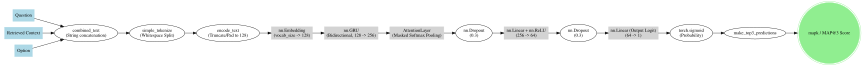

In [19]:
dot = Digraph("BiGRU_Attention_Pipeline", format="png")
dot.attr(rankdir="LR", size="12,5", fontsize="12", splines="true")

dot.node("A", "Question", shape="box", style="filled", color="lightblue")
dot.node("B", "Retrieved Context", shape="box", style="filled", color="lightblue")
dot.node("C", "Option", shape="box", style="filled", color="lightblue")
dot.node("D", "combined_text\n(String concatenation)", shape="ellipse")
dot.node("E", "simple_tokenize\n(Whitespace Split)", shape="ellipse")
dot.node("F", "encode_text\n(Truncate/Pad to 128)", shape="ellipse")
dot.node("G", "nn.Embedding\n(vocab_size -> 128)", shape="box", style="filled", color="lightgrey")
dot.node("H", "nn.GRU\n(Bidirectional, 128 -> 256)", shape="box", style="filled", color="lightgrey")
dot.node("I", "AttentionLayer\n(Masked Softmax Pooling)", shape="box", style="filled", color="lightgrey")
dot.node("J", "nn.Dropout\n(0.3)", shape="ellipse")
dot.node("K", "nn.Linear + nn.ReLU\n(256 -> 64)", shape="box", style="filled", color="lightgrey")
dot.node("L", "nn.Dropout\n(0.3)", shape="ellipse")
dot.node("M", "nn.Linear (Output Logit)\n(64 -> 1)", shape="box", style="filled", color="lightgrey")
dot.node("N", "torch.sigmoid\n(Probability)", shape="ellipse")
dot.node("O", "make_top3_predictions", shape="ellipse")
dot.node("P", "mapk / MAP@3 Score", shape="doublecircle", style="filled", color="lightgreen")

dot.edges([
    ("A", "D"),
    ("B", "D"),
    ("C", "D"),
    ("D", "E"),
    ("E", "F"),
    ("F", "G"),
    ("G", "H"),
    ("H", "I"),
    ("I", "J"),
    ("J", "K"),
    ("K", "L"),
    ("L", "M"),
    ("M", "N"),
    ("N", "O"),
    ("O", "P")
])

display(dot)

In [20]:
# Scratch vocabulary

def simple_tokenize(text):
    return str(text).split()

counter = Counter()
for text in train_long["combined_text"].tolist():
    counter.update(simple_tokenize(text))

vocab = {"<PAD>": 0, "<UNK>": 1}
for word, freq in counter.items():
    if freq >= 2:
        vocab[word] = len(vocab)

def encode_text(text, vocab, max_len=128):
    tokens = simple_tokenize(text)
    ids = [vocab.get(tok, vocab["<UNK>"]) for tok in tokens[:max_len]]

    if len(ids) < max_len:
        ids = ids + [vocab["<PAD>"]] * (max_len - len(ids))

    return ids


# Scratch Dataset
class ScratchDataset(Dataset):
    def __init__(self, df, vocab, max_len=128, is_train=True):
        self.df = df.reset_index(drop=True)
        self.vocab = vocab
        self.max_len = max_len
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        item = {
            'input_ids': torch.tensor(encode_text(row['combined_text'], self.vocab, self.max_len), dtype=torch.long),
            'id': row['id'],
            'option_label': row['option_label']
        }
        if self.is_train:
            item['target'] = torch.tensor(row['target'], dtype=torch.float)
        return item

train_dataset_scratch = ScratchDataset(train_long, vocab, MAX_LEN_SCRATCH, is_train=True)
val_dataset_scratch = ScratchDataset(val_long, vocab, MAX_LEN_SCRATCH, is_train=True)

train_loader_scratch = DataLoader(train_dataset_scratch, batch_size=BATCH_SIZE_SCRATCH, shuffle=True)
val_loader_scratch = DataLoader(val_dataset_scratch, batch_size=BATCH_SIZE_SCRATCH, shuffle=False)

In [21]:
# Attention layer for scracth model
class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x, mask):
        scores = self.attn(x).squeeze(-1)
        scores = scores.masked_fill(mask == 0, -1e9)
        weights = torch.softmax(scores, dim=1)
        context = torch.sum(x * weights.unsqueeze(-1), dim=1)
        return context


class BiGRUAttentionModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.bigru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.attention = AttentionLayer(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.dense = nn.Linear(hidden_dim * 2, 64)
        self.relu = nn.ReLU()
        self.output = nn.Linear(64, 1)

    def forward(self, input_ids):
        mask = (input_ids != 0).long()
        x = self.embedding(input_ids)
        x, _ = self.bigru(x)
        x = self.attention(x, mask)
        x = self.dropout(x)
        x = self.relu(self.dense(x))
        x = self.dropout(x)
        x = self.output(x).squeeze(-1)
        return x

In [22]:
# evaluate scratch model
def evaluate_scratch_model(model, dataloader, val_main_df, device):
    model.eval()
    criterion = nn.BCEWithLogitsLoss()

    all_probs = []
    all_targets = []
    records = []
    total_loss = 0.0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            targets = batch['target'].to(device)

            logits = model(input_ids)
            loss = criterion(logits, targets)
            probs = torch.sigmoid(logits).cpu().numpy()

            total_loss += loss.item()
            all_probs.extend(probs.tolist())
            all_targets.extend(targets.cpu().numpy().tolist())

            for i in range(len(probs)):
                records.append({
                    'id': batch['id'][i].item() if torch.is_tensor(batch['id'][i]) else batch['id'][i],
                    'option_label': batch['option_label'][i],
                    'score': probs[i]
                })

    pred_df = pd.DataFrame(records)
    top3_df = make_top3_predictions(pred_df, 'score')
    eval_df = top3_df.merge(val_main_df[['id', 'answer']], on='id', how='left')
    map3 = mapk(eval_df['answer'].tolist(), eval_df['top3'].tolist(), k=3)

    y_pred = (np.array(all_probs) > 0.5).astype(int)
    loss = total_loss / len(dataloader)
    acc = accuracy_score(all_targets, y_pred)
    f1 = f1_score(all_targets, y_pred, zero_division=0)

    return {'loss': loss, 'accuracy': acc, 'f1': f1, 'map3': map3}


In [23]:
# training scratch model
def train_scratch_model(model, train_loader, val_loader, val_main_df, epochs=5, lr=2e-3, device='cpu'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    history = []
    best_map3 = 0.0
    best_state = None

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0

        for batch in tqdm(train_loader, desc=f'Scratch Epoch {epoch+1}'):
            input_ids = batch['input_ids'].to(device)
            targets = batch['target'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids)
            loss = criterion(logits, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()

            total_train_loss += loss.item()
        val_metrics = evaluate_scratch_model(model, val_loader, val_main_df, device)
        
        epoch_result = {
            'epoch': epoch + 1,
            'train_loss': total_train_loss / len(train_loader),
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
            'val_f1_macro': val_metrics['f1'],
            'val_map3': val_metrics['map3']
        }
        history.append(epoch_result)
        
        wandb.log({
            "epoch": epoch + 1,
            "train/loss": epoch_result["train_loss"],
            "val/loss": epoch_result["val_loss"],
            "val/accuracy": epoch_result["val_accuracy"],
            "val/f1_macro": epoch_result["val_f1_macro"],
            "val/map3": epoch_result["val_map3"]
        })

        print(f"Epoch {epoch+1}")
        print(f"Train Loss: {epoch_result['train_loss']:.5f}")
        print(f"Val Loss: {epoch_result['val_loss']:.5f} | Val Acc: {epoch_result['val_accuracy']:.5f} | Val F1 Macro: {epoch_result['val_f1_macro']:.5f} | Val MAP@3: {epoch_result['val_map3']:.5f}")

        if val_metrics['map3'] > best_map3:
            best_map3 = val_metrics['map3']
            best_state = copy.deepcopy(model.state_dict())  # deepcopy: state_dict() alone returns live tensor
                                                              # references that keep changing as training continues

    if best_state is not None:
        model.load_state_dict(best_state)
        
    return model, pd.DataFrame(history)

In [24]:
# W&B Run - Scratch BiGRU + Attention

scratch_run = wandb.init(
    entity="24f1000881-indian-institute-of-technology-madras",
    project="DL-24f1000881-notebook-t22026",
    name="BiGRU-Attention-Scratch",
    config={
        "model": "BiGRU + Attention",
        "embedding_dim": EMBED_DIM,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "batch_size": BATCH_SIZE_SCRATCH,
        "epochs": SCRATCH_EPOCHS,
        "learning_rate": SCRATCH_LR,
        "vocab_size": len(vocab),
        "max_len": MAX_LEN_SCRATCH
    }
)
scratch_model = BiGRUAttentionModel(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT
)

scratch_model, scratch_history = train_scratch_model(
    scratch_model,
    train_loader_scratch,
    val_loader_scratch,
    val_main,
    epochs=SCRATCH_EPOCHS,
    lr=SCRATCH_LR,
    device=DEVICE
)

display(scratch_history)

best_scratch_row = scratch_history.sort_values('val_map3', ascending=False).iloc[0]

model_filename = "bigru_attention_model.pth"
torch.save(scratch_model.state_dict(), model_filename)

joblib.dump(vocab, "bigru_vocab.pkl")

wandb.save(model_filename)

print("Model 1 - BiGRU Attention Scratch Model")
print("Validation Loss:", round(best_scratch_row['val_loss'], 5))
print("Validation Accuracy:", round(best_scratch_row['val_accuracy'], 5))
print("Validation F1 Macro:", round(best_scratch_row['val_f1_macro'], 5))
print("Validation MAP@3:", round(best_scratch_row['val_map3'], 5))

scratch_run.finish()

wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260802_155448-ze0u6hyj
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run BiGRU-Attention-Scratch
wandb: ⭐️ View project at https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026
wandb: 🚀 View run at https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026/runs/ze0u6hyj


Scratch Epoch 1:   0%|          | 0/110 [00:00<?, ?it/s]

Epoch 1
Train Loss: 0.47746
Val Loss: 0.34578 | Val Acc: 0.85284 | Val F1 Macro: 0.44540 | Val MAP@3: 0.90057


Scratch Epoch 2:   0%|          | 0/110 [00:00<?, ?it/s]

Epoch 2
Train Loss: 0.24218
Val Loss: 0.14149 | Val Acc: 0.93920 | Val F1 Macro: 0.83664 | Val MAP@3: 0.97159


...

Epoch 5
Train Loss: 0.05964
Val Loss: 0.05647 | Val Acc: 0.96989 | Val F1 Macro: 0.92587 | Val MAP@3: 0.99148


,epoch,train_loss,val_loss,val_accuracy,val_f1_macro,val_map3
0,1,0.477456,0.345785,0.852841,0.445396,0.900568
1,2,0.242178,0.141489,0.939205,0.836641,0.971591
2,3,0.114424,0.103036,0.950568,0.865948,0.977273
3,4,0.073938,0.061500,0.965341,0.906870,0.983902
4,5,0.059636,0.056470,0.969886,0.925874,0.991477


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: updating run metadata


Model 1 - BiGRU Attention Scratch Model
Validation Loss: 0.05647
Validation Accuracy: 0.96989
Validation F1 Macro: 0.92587
Validation MAP@3: 0.99148


wandb: uploading history steps 0-4, summary, console lines 0-20
wandb: 
wandb: Run history:
wandb:        epoch ▁▃▅▆█
wandb:   train/loss █▄▂▁▁
wandb: val/accuracy ▁▆▇██
wandb: val/f1_macro ▁▇▇██
wandb:     val/loss █▃▂▁▁
wandb:     val/map3 ▁▆▇▇█
wandb: 
wandb: Run summary:
wandb:        epoch 5
wandb:   train/loss 0.05964
wandb: val/accuracy 0.96989
wandb: val/f1_macro 0.92587
wandb:     val/loss 0.05647
wandb:     val/map3 0.99148
wandb: 
wandb: 🚀 View run BiGRU-Attention-Scratch at: https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026/runs/ze0u6hyj
wandb: ⭐️ View project at: https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 1 other file(s)
wandb: Find logs at: ./wandb/run-20260802_155448-ze0u6hyj/logs


### Observations:
- Successfully learned sequential information from the question and answer options.
- Bidirectional processing captured context from both past and future words.
- The attention mechanism focused on the most informative words instead of treating every word equally.
Achieved significantly higher validation metrics than the baseline TF-IDF model.
- Generalized well on the validation dataset.
- Trained efficiently because GRU has fewer parameters than LSTM.
- Demonstrated that contextual sequence learning improves MCQ prediction performance.

# Model 2 - Electra Base

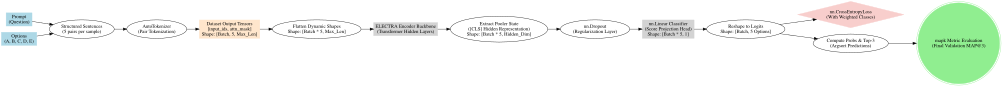

In [25]:
dot = Digraph("ELECTRA_MCQ_Pipeline", format="png")
dot.attr(rankdir="LR", size="14,6", fontsize="12", splines="true")
dot.node("A", "Prompt\n(Question)", shape="box", style="filled", color="lightblue")
dot.node("B", "Options\n(A, B, C, D, E)", shape="box", style="filled", color="lightblue")
dot.node("C", "Structured Sentences\n(5 pairs per sample)", shape="ellipse")
dot.node("D", "AutoTokenizer\n(Pair Tokenization)", shape="ellipse")
dot.node("E", "Dataset Output Tensors\n[input_ids, attn_mask]\nShape: [Batch, 5, Max_Len]", shape="box", style="filled", color="#ffe6cc")
dot.node("F", "Flatten Dynamic Shapes\nShape: [Batch * 5, Max_Len]", shape="ellipse")
dot.node("G", "ELECTRA Encoder Backbone\n(Transformer Hidden Layers)", shape="box", style="filled", color="lightgrey")
dot.node("H", "Extract Pooler State\n([CLS] Hidden Representation)\nShape: [Batch * 5, Hidden_Dim]", shape="ellipse")
dot.node("I", "nn.Dropout\n(Regularization Layer)", shape="ellipse")
dot.node("J", "nn.Linear Classifier\n(Score Projection Head)\nShape: [Batch * 5, 1]", shape="box", style="filled", color="lightgrey")
dot.node("K", "Reshape to Logits\nShape: [Batch, 5 Options]", shape="ellipse")
dot.node("L", "nn.CrossEntropyLoss\n(With Weighted Classes)", shape="diamond", style="filled", color="#f8cecc")
dot.node("M", "Compute Probs & Top-3\n(Argsort Predictions)", shape="ellipse")
dot.node("N", "mapk Metric Evaluation\n(Final Validation MAP@3)", shape="doublecircle", style="filled", color="lightgreen")

dot.edges([
    ("A", "C"),
    ("B", "C"),
    ("C", "D"),
    ("D", "E"),
    ("E", "F"),
    ("F", "G"),
    ("G", "H"),
    ("H", "I"),
    ("I", "J"),
    ("J", "K"),
    ("K", "L"),
    ("K", "M"),
    ("M", "N")
])

display(dot)

In [26]:
# tokenizer 
mc_tokenizer = AutoTokenizer.from_pretrained(MC_MODEL_NAME)
print("Loaded tokenizer:", MC_MODEL_NAME)

class ElectraMCQDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=320, is_train=True):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_train = is_train
        self.label2id = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        prompt = str(row["prompt"]).strip()

        question_text = f"Question:\n{prompt}\n\nTask:\nSelect the most appropriate answer."

        options = [
            str(row["A"]).strip(),
            str(row["B"]).strip(),
            str(row["C"]).strip(),
            str(row["D"]).strip(),
            str(row["E"]).strip()
        ]

        first_sentences = [question_text.strip()] * 5
        second_sentences = [f"Candidate Answer:\n{option}".strip() for option in options]

        encoded = self.tokenizer(
            first_sentences,
            second_sentences,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        item = {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0)
        }

        if "token_type_ids" in encoded:
            item["token_type_ids"] = encoded["token_type_ids"].squeeze(0)

        if self.is_train:
            ans_key = row["answer"]
            ans_id = self.label2id.get(ans_key, 0)
            item["labels"] = torch.tensor(ans_id, dtype=torch.long)

        if "id" in row and pd.notna(row["id"]):
            try:
                item["id"] = torch.tensor(int(row["id"]), dtype=torch.long)
            except (ValueError, TypeError):
                item["id"] = torch.tensor(idx, dtype=torch.long)

        return item

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded tokenizer: google/electra-base-discriminator


In [27]:
# DataLoaders 

train_dataset_mc = ElectraMCQDataset(train_main, mc_tokenizer, max_len=MAX_LEN, is_train=True)
val_dataset_mc = ElectraMCQDataset(val_main, mc_tokenizer, max_len=MAX_LEN, is_train=True)
test_dataset_mc = ElectraMCQDataset(test_df, mc_tokenizer, max_len=MAX_LEN, is_train=False)


train_loader_mc = DataLoader(
    train_dataset_mc,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    pin_memory=torch.cuda.is_available()
)

val_loader_mc = DataLoader(
    val_dataset_mc,
    batch_size=VALID_BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)

test_loader_mc = DataLoader(
    test_dataset_mc,
    batch_size=VALID_BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)

In [28]:
# eval function

def evaluate_electra_mc(model, dataloader, device, class_weights=None):
    model.eval()
    weights = class_weights.to(device) if class_weights is not None else None
    criterion = nn.CrossEntropyLoss(weight=weights)

    total_loss = 0.0
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            model_inputs = {
                "input_ids": input_ids,
                "attention_mask": attention_mask
            }

            if "token_type_ids" in batch:
                model_inputs["token_type_ids"] = batch["token_type_ids"].to(device)

            outputs = model(**model_inputs)
            logits = outputs.logits
            loss = criterion(logits, labels)

            total_loss += loss.item()
            all_logits.append(logits.detach().cpu().numpy())

            all_labels.append(labels.detach().cpu().numpy())

    all_logits = np.concatenate(all_logits, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    metrics, y_pred, probs = compute_multiclass_metrics(all_labels, all_logits)

    ranked_predictions = []
    for row_probs in probs:
        ranked_idx = np.argsort(-row_probs)[:3]
        ranked_labels = [ID2LABEL[idx] for idx in ranked_idx]
        ranked_predictions.append(ranked_labels)

    true_answers = [ID2LABEL[x] for x in all_labels]
    val_map3 = mapk(true_answers, ranked_predictions, k=3)

    return {
        "loss": total_loss / len(dataloader),
        "accuracy": metrics["accuracy"],
        "f1": metrics["f1_macro"],
        "map3": val_map3
    }

In [29]:
def train_electra_mc(
    model,
    train_loader,
    val_loader,
    epochs=4,
    lr=2e-5,
    weight_decay=0.01,
    device="cpu",
    class_weights=None,
    accumulation_steps=1
):
    model = model.to(device)
    weights = class_weights.to(device) if class_weights is not None else None
    criterion = nn.CrossEntropyLoss(weight=weights)

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    steps_per_epoch = math.ceil(len(train_loader) / accumulation_steps)
    total_steps = steps_per_epoch * epochs
    warmup_steps = int(0.1 * total_steps)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    history = []
    best_map3 = -1.0
    best_state = None

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0
        train_logits = []
        train_labels = []
        optimizer.zero_grad()

        progress_bar = tqdm(train_loader, desc=f"ELECTRA Epoch {epoch+1}")

        for step, batch in enumerate(progress_bar):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            model_inputs = {
                "input_ids": input_ids,
                "attention_mask": attention_mask
            }

            if "token_type_ids" in batch:
                model_inputs["token_type_ids"] = batch["token_type_ids"].to(device)

            outputs = model(**model_inputs)
            logits = outputs.logits
            loss = criterion(logits, labels)

            (loss / accumulation_steps).backward()

            is_last_batch = (step + 1) == len(train_loader)
            if (step + 1) % accumulation_steps == 0 or is_last_batch:
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

            total_train_loss += loss.item()
            train_logits.append(logits.detach().cpu().numpy())
            train_labels.append(labels.detach().cpu().numpy())

        train_logits = np.concatenate(train_logits, axis=0)
        train_labels = np.concatenate(train_labels, axis=0)
        train_metrics, _, _ = compute_multiclass_metrics(train_labels, train_logits)

        val_metrics = evaluate_electra_mc(model, val_loader, device, class_weights=class_weights)

        epoch_result = {
            "epoch": epoch + 1,
            "train_loss": total_train_loss / len(train_loader),
            "train_accuracy": train_metrics["accuracy"],
            "train_f1": train_metrics["f1_macro"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_f1_macro": val_metrics["f1"], 
            "val_map3": val_metrics["map3"]
        }
        history.append(epoch_result)

        print(f"\nEpoch {epoch+1}")
        print(f"Train Loss: {epoch_result['train_loss']:.5f} | Train Acc: {epoch_result['train_accuracy']:.5f} | Train F1: {epoch_result['train_f1']:.5f}")
        print(f"Val   Loss: {epoch_result['val_loss']:.5f} | Val   Acc: {epoch_result['val_accuracy']:.5f} | Val F1 Macro: {epoch_result['val_f1_macro']:.5f} | Val MAP@3: {epoch_result['val_map3']:.5f}")

        if epoch_result["val_map3"] > best_map3:
            best_map3 = epoch_result["val_map3"]
            best_state = copy.deepcopy(model.state_dict())

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    return model, history_df

In [30]:
def compute_class_weights(df, label_col="answer"):
    counts = df[label_col].map(LABEL2ID).value_counts().reindex(range(len(LABEL2ID)), fill_value=1)
    total = counts.sum()
    weights = total / (len(LABEL2ID) * counts)
    return torch.tensor(weights.values, dtype=torch.float)

main_class_weights = compute_class_weights(train_main)
print("Class weights (A, B, C, D, E):", main_class_weights.tolist())


Class weights (A, B, C, D, E): [1.0571428537368774, 0.794350266456604, 0.9012820720672607, 1.129317283630371, 1.2497777938842773]


In [31]:
mc_model = AutoModelForMultipleChoice.from_pretrained(MC_MODEL_NAME).to(DEVICE)

electra_run = start_run(
    "model2_pretrained_electra_base",
    {
        "model_type": "Pretrained Transformer",
        "model_name": MC_MODEL_NAME,
        "architecture": "AutoModelForMultipleChoice",
        "max_len": MAX_LEN,
        "train_batch_size": TRAIN_BATCH_SIZE,
        "valid_batch_size": VALID_BATCH_SIZE,
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "max_grad_norm": MAX_GRAD_NORM,
        "accumulation_steps": ACCUMULATION_STEPS,
        "effective_batch_size": TRAIN_BATCH_SIZE * ACCUMULATION_STEPS,
        "class_weights": main_class_weights.tolist()
    }
)
mc_model, electra_history = train_electra_mc(
    mc_model,
    train_loader_mc,
    val_loader_mc,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    device=DEVICE,
    class_weights=main_class_weights,
    accumulation_steps=ACCUMULATION_STEPS
)

display(electra_history)

best_row = electra_history.sort_values(
    "val_map3",
    ascending=False
).iloc[0]

print("Model 2 - ELECTRA-base")
print("Validation Loss       :", round(best_row["val_loss"], 5))
print("Validation Accuracy  :", round(best_row["val_accuracy"], 5))
# --- CHANGED KEY AND LABEL TO MACRO ---
print("Validation F1 Macro  :", round(best_row["val_f1_macro"], 5))
print("Validation MAP@3     :", round(best_row["val_map3"], 5))

model_filename = "electra_base_best.pth"
torch.save(mc_model.state_dict(), model_filename)

mc_tokenizer.save_pretrained("electra_base_tokenizer")

wandb.save(model_filename)

wandb.log({
    "best_val_loss": float(best_row["val_loss"]),
    "best_val_accuracy": float(best_row["val_accuracy"]),
    "best_val_f1_macro": float(best_row["val_f1_macro"]),
    "best_val_map3": float(best_row["val_map3"])
})

electra_run.finish()

print("\nModel saved successfully!")
print("Weights   : electra_base_best.pth")
print("Tokenizer : electra_base_tokenizer/")

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForMultipleChoice LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
electra.embeddings_project.weight                 | UNEXPECTED | 
electra.embeddings_project.bias                   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
sequence_summary.summary.weight                   | MISSING    | 
classifier.bias                                   | MISSING    | 
sequence_summary.summary.bias                     | MISSING    | 
classifier.weight                                 | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260802_155509-cmsb81h8
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run model2_pretrained_electra_base
wandb: ⭐️ View project at https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026
wandb: 🚀 View run at https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026/runs/cmsb81h8


...


Epoch 6
Train Loss: 0.12623 | Train Acc: 0.95519 | Train F1: 0.95573
Val   Loss: 0.11724 | Val   Acc: 0.99432 | Val F1 Macro: 0.99433 | Val MAP@3: 0.99716


,epoch,train_loss,train_accuracy,train_f1,val_loss,val_accuracy,val_f1_macro,val_map3
0,1,1.520726,0.339972,0.339607,1.142878,0.721591,0.716903,0.817235
1,2,0.848783,0.714794,0.714389,0.654013,0.909091,0.907795,0.939867
2,3,0.484287,0.843528,0.842098,0.285044,0.946023,0.944599,0.971591
3,4,0.270362,0.908250,0.908197,0.186067,0.963068,0.964831,0.973011
4,5,0.159390,0.940256,0.940056,0.140352,0.985795,0.984970,0.992424
5,6,0.126229,0.955192,0.955729,0.117236,0.994318,0.994332,0.997159


Model 2 - ELECTRA-base
Validation Loss       : 0.11724
Validation Accuracy  : 0.99432
Validation F1 Macro  : 0.99433
Validation MAP@3     : 0.99716


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: updating run metadata
wandb: uploading history steps 0-0, summary, console lines 20-29
wandb: uploading electra_base_best.pth
wandb: 
wandb: Run history:
wandb: best_val_accuracy ▁
wandb: best_val_f1_macro ▁
wandb:     best_val_loss ▁
wandb:     best_val_map3 ▁
wandb: 
wandb: Run summary:
wandb: best_val_accuracy 0.99432
wandb: best_val_f1_macro 0.99433
wandb:     best_val_loss 0.11724
wandb:     best_val_map3 0.99716
wandb: 
wandb: 🚀 View run model2_pretrained_electra_base at: https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026/runs/cmsb81h8
wandb: ⭐️ View project at: https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 1 other file(s)
wandb: Find logs at: ./wandb/run-20260802_155509-cmsb81h8/logs



Model saved successfully!
Weights   : electra_base_best.pth
Tokenizer : electra_base_tokenizer/


### Observations:
- Achieved the highest validation Accuracy, F1-score, and MAP@3 among all models.
- Leveraged pretrained language knowledge, reducing the need for learning language patterns from scratch.
Understood contextual relationships between questions and answer options effectively.
- Required the longest training time and highest computational resources.
- Produced the most consistent validation performance across epochs.
- Selected as the final model for generating Kaggle predictions.
- Demonstrated the advantage of transfer learning for NLP classification tasks.

# Model 3 - TF-IDF + PYTORCH NEURAL NETWORK

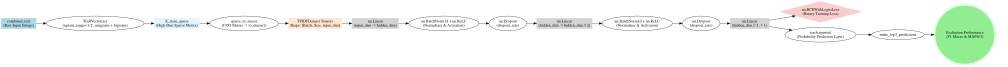

In [32]:
dot = Digraph("TFIDF_MLP_Pipeline", format="png")
dot.attr(rankdir="LR", size="14,6", fontsize="12", splines="true")
dot.node("A", "combined_text\n(Raw Input Strings)", shape="box", style="filled", color="lightblue")
dot.node("B", "TfidfVectorizer\n(ngram_range='1-2', unigrams + bigrams)", shape="ellipse")
dot.node("C", "X_train_sparse\n(High-Dim Sparse Matrix)", shape="box", style="filled", color="#e1f5fe")
dot.node("D", "sparse_to_tensor\n(COO Matrix -> to_dense())", shape="ellipse")
dot.node("E", "TFIDFDataset Tensors\nShape: [Batch_Size, input_dim]", shape="box", style="filled", color="#ffe6cc")
dot.node("F", "nn.Linear\n(input_dim -> hidden_dim)", shape="box", style="filled", color="lightgrey")
dot.node("G", "nn.BatchNorm1d + nn.ReLU\n(Normalizer & Activation)", shape="ellipse")
dot.node("H", "nn.Dropout\n(dropout_rate)", shape="ellipse")
dot.node("I", "nn.Linear\n(hidden_dim -> hidden_dim // 2)", shape="box", style="filled", color="lightgrey")
dot.node("J", "nn.BatchNorm1d + nn.ReLU\n(Normalizer & Activation)", shape="ellipse")
dot.node("K", "nn.Dropout\n(dropout_rate)", shape="ellipse")
dot.node("L", "nn.Linear\n(hidden_dim // 2 -> 1)", shape="box", style="filled", color="lightgrey")
dot.node("M", "nn.BCEWithLogitsLoss\n(Binary Training Loss)", shape="diamond", style="filled", color="#f8cecc")
dot.node("N", "torch.sigmoid\n(Probability Prediction Layer)", shape="ellipse")
dot.node("O", "make_top3_predictions", shape="ellipse")
dot.node("P", "Evaluation Performance\n(F1 Macro & MAP@3)", shape="doublecircle", style="filled", color="lightgreen")

dot.edges([
    ("A", "B"),
    ("B", "C"),
    ("C", "D"),
    ("D", "E"),
    ("E", "F"),
    ("F", "G"),
    ("G", "H"),
    ("H", "I"),
    ("I", "J"),
    ("J", "K"),
    ("K", "L"),
    ("L", "M"),
    ("L", "N"),
    ("N", "O"),
    ("O", "P")
])
display(dot)

In [33]:
dl_run = start_run(
    "model3_tfidf_mlp_dl",
    {
        "model_type": "Custom DL (MLP)",
        "model_name": "TF-IDF + PyTorch Neural Network",
        "max_features": MAX_FEATURES,
        "ngram_range": "1-2"
    }
)

tfidf = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=NGRAM_RANGE,
    stop_words="english"
)

print("Extracting features using TF-IDF...")
X_train_sparse = tfidf.fit_transform(train_long["combined_text"])
X_val_sparse = tfidf.transform(val_long["combined_text"])

y_train_dl = train_long["target"].values
y_val_dl = val_long["target"].values

def sparse_to_tensor(sparse_matrix):
    coo = sparse_matrix.tocoo()
    values = coo.data
    indices = np.vstack((coo.row, coo.col))
    i = torch.LongTensor(indices)
    v = torch.FloatTensor(values)
    shape = coo.shape
    return torch.sparse_coo_tensor(i, v, torch.Size(shape)).to_dense()

print("Converting matrices to PyTorch Tensors...")
X_train_tensor = sparse_to_tensor(X_train_sparse)
X_val_tensor = sparse_to_tensor(X_val_sparse)

class TFIDFDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = torch.tensor(y, dtype=torch.float32)
        
    def __len__(self):
        return len(self.y)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TFIDFDataset(X_train_tensor, y_train_dl)
val_dataset = TFIDFDataset(X_val_tensor, y_val_dl)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_SCRATCH, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_SCRATCH, shuffle=False)

class CustomMLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout_rate=0.3):
        super(CustomMLPClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(hidden_dim // 2, 1)
        )
        
    def forward(self, x):
        return self.network(x)

input_dim = X_train_sparse.shape[1]
custom_dl_model = CustomMLPClassifier(
    input_dim=input_dim, 
    hidden_dim=HIDDEN_DIM, 
    dropout_rate=DROPOUT
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(custom_dl_model.parameters(), lr=SCRATCH_LR, weight_decay=0.01)

for epoch in range(SCRATCH_EPOCHS):
    custom_dl_model.train()
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = custom_dl_model(batch_X).squeeze(1)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

custom_dl_model.eval()
val_preds = []

with torch.no_grad():
    for batch_X, _ in val_loader:
        batch_X = batch_X.to(DEVICE)
        outputs = torch.sigmoid(custom_dl_model(batch_X)).squeeze(1)
        val_preds.extend(outputs.cpu().numpy())

val_dl = val_long.copy()
val_dl["score"] = val_preds

dl_binary_metrics = compute_binary_metrics(y_val_dl, val_dl["score"].values)

dl_top3 = make_top3_predictions(val_dl, "score")
dl_eval = dl_top3.merge(val_main[["id", "answer"]], on="id")
dl_map3 = mapk(dl_eval["answer"].tolist(), dl_eval["top3"].tolist())
val_f1_macro_score = dl_binary_metrics["f1"]

print("Model 3 - TF-IDF Custom DL (MLP)")
print("Validation Loss    :", round(dl_binary_metrics["loss"], 5))
print("Validation Accuracy:", round(dl_binary_metrics["accuracy"], 5))
print("Validation F1 Macro:", round(val_f1_macro_score, 5))
print("Validation MAP@3   :", round(dl_map3, 5))

model_filename = "custom_dl_model.pt"
tfidf_filename = "custom_dl_tfidf.pkl"

torch.save(custom_dl_model.state_dict(), model_filename)
joblib.dump(tfidf, tfidf_filename)

wandb.save(model_filename)
wandb.save(tfidf_filename)
print("\nCustom MLP model and TF-IDF assets saved successfully!")

wandb.log({
    "val_loss": dl_binary_metrics["loss"],
    "val_accuracy": dl_binary_metrics["accuracy"],
    "val_f1_macro": val_f1_macro_score,
    "val_map3": dl_map3
})

dl_run.finish()

wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260802_162721-jeunqyla
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run model3_tfidf_mlp_dl
wandb: ⭐️ View project at https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026
wandb: 🚀 View run at https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026/runs/jeunqyla


Extracting features using TF-IDF...
Converting matrices to PyTorch Tensors...


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Model 3 - TF-IDF Custom DL (MLP)
Validation Loss    : 0.05766
Validation Accuracy: 0.97443
Validation F1 Macro: 0.93469
Validation MAP@3   : 0.97348

Custom MLP model and TF-IDF assets saved successfully!


wandb: updating run metadata
wandb: 
wandb: Run history:
wandb: val_accuracy ▁
wandb: val_f1_macro ▁
wandb:     val_loss ▁
wandb:     val_map3 ▁
wandb: 
wandb: Run summary:
wandb: val_accuracy 0.97443
wandb: val_f1_macro 0.93469
wandb:     val_loss 0.05766
wandb:     val_map3 0.97348
wandb: 
wandb: 🚀 View run model3_tfidf_mlp_dl at: https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026/runs/jeunqyla
wandb: ⭐️ View project at: https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 2 other file(s)
wandb: Find logs at: ./wandb/run-20260802_162721-jeunqyla/logs


### Observations:
- Improved upon the linear baseline by introducing non-linear learning.
- Learned more complex feature interactions than Logistic Regression.
- Still depended on TF-IDF features rather than contextual embeddings.
- Achieved competitive validation performance but remained below BiGRU and ELECTRA.
- Showed that adding a neural network alone cannot fully compensate for the lack of contextual language understanding.
- Served as an intermediate approach between traditional ML and deep learning.

# Model Comparison

In [34]:
results = [
    {
        "Model": "Baseline - TF-IDF + Logistic Regression",
        "Validation Loss": baseline_metrics["loss"],
        "Validation Accuracy": baseline_metrics["accuracy"],
        "Validation F1 Macro": val_f1_macro_score,  
        "Validation MAP@3": baseline_map3
    },
    {
        "Model": "TF-IDF + MLP Classifier (Custom DL)",
        "Validation Loss": dl_binary_metrics["loss"],
        "Validation Accuracy": dl_binary_metrics["accuracy"],
        "Validation F1 Macro": dl_binary_metrics["f1"], 
        "Validation MAP@3": dl_map3
    },
    {
        "Model": "Embedding -> BiGRU -> Attention",
        "Validation Loss": best_scratch_row["val_loss"],
        "Validation Accuracy": best_scratch_row["val_accuracy"],
        "Validation F1 Macro": best_scratch_row["val_f1_macro"], 
        "Validation MAP@3": best_scratch_row["val_map3"]
    },
    {
        "Model": "ELECTRA-base Pretrained Model",
        "Validation Loss": best_row["val_loss"],
        "Validation Accuracy": best_row["val_accuracy"],
        "Validation F1 Macro": best_row["val_f1_macro"],  
        "Validation MAP@3": best_row["val_map3"]
    }
]

results_df = (
    pd.DataFrame(results)
      .sort_values(by=["Validation MAP@3", "Validation Loss"], ascending=[False, True])
      .reset_index(drop=True)
)

display(results_df)

best_model_name = results_df.loc[0, "Model"]
print("Best model on validation MAP@3:", best_model_name)

,Model,Validation Loss,Validation Accuracy,Validation F1 Macro,Validation MAP@3
0,ELECTRA-base Pretrained Model,0.117236,0.994318,0.994332,0.997159
1,Embedding -> BiGRU -> Attention,0.056470,0.969886,0.925874,0.991477
2,TF-IDF + MLP Classifier (Custom DL),0.057665,0.974432,0.934688,0.973485
3,Baseline - TF-IDF + Logistic Regression,0.339612,0.836932,0.934688,0.969223


Best model on validation MAP@3: ELECTRA-base Pretrained Model


# Error Analysis 

Classification Report - ELECTRA-base (Validation Set)
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        60
           B       1.00      0.99      0.99        76
           C       0.99      1.00      0.99        89
           D       1.00      1.00      1.00        65
           E       0.98      0.98      0.98        62

    accuracy                           0.99       352
   macro avg       0.99      0.99      0.99       352
weighted avg       0.99      0.99      0.99       352



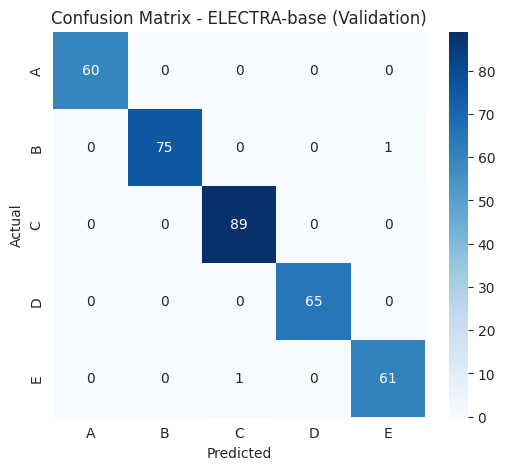

In [35]:
mc_model.eval()
all_val_logits, all_val_labels = [], []

with torch.no_grad():
    for batch in val_loader_mc:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        model_inputs = {"input_ids": input_ids, "attention_mask": attention_mask}
        if "token_type_ids" in batch:
            model_inputs["token_type_ids"] = batch["token_type_ids"].to(DEVICE)
        outputs = mc_model(**model_inputs)
        all_val_logits.append(outputs.logits.detach().cpu().numpy())
        all_val_labels.append(labels.detach().cpu().numpy())

all_val_logits = np.concatenate(all_val_logits, axis=0)
all_val_labels = np.concatenate(all_val_labels, axis=0)
val_preds = np.argmax(all_val_logits, axis=1)

print("Classification Report - ELECTRA-base (Validation Set)")
print(classification_report(all_val_labels, val_preds, target_names=OPTION_LABELS))

cm = confusion_matrix(all_val_labels, val_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=OPTION_LABELS, yticklabels=OPTION_LABELS)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ELECTRA-base (Validation)")
plt.show()


### Observations:
- The ELECTRA model achieved an overall validation accuracy of 99%.
- Precision, Recall, and F1-score are close to 1.00 for all classes, indicating excellent performance.
- Classes A and D were classified perfectly with no prediction errors.
- Only two misclassifications occurred in the entire validation dataset.
- The confusion matrix is dominated by diagonal values, showing highly accurate predictions.
- These results confirm that ELECTRA was the best-performing model and was selected for final test prediction.

# Inference for the model

In [36]:
mc_model.eval()
ranked_predictions = []

with torch.no_grad():
    for batch in tqdm(test_loader_mc, desc="ELECTRA Test Inference"):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        model_inputs = {
            "input_ids": input_ids,
            "attention_mask": attention_mask
        }

        if "token_type_ids" in batch:
            model_inputs["token_type_ids"] = batch["token_type_ids"].to(DEVICE)

        outputs = mc_model(**model_inputs)
        logits = outputs.logits.detach().cpu().numpy()
        probs = stable_softmax(logits)

        for row_probs in probs:
            top3_idx = np.argsort(-row_probs)[:3]
            ranked_predictions.append(" ".join([ID2LABEL[i] for i in top3_idx]))

submission = pd.DataFrame({
    "ID": test_df["id"].values,
    "Prediction": ranked_predictions
})

display(submission.head())
submission.to_csv("submission_electra_mc.csv", index=False)
print("submission_electra_mc.csv saved successfully")

ELECTRA Test Inference:   0%|          | 0/125 [00:00<?, ?it/s]

,ID,Prediction
0,1,A B E
1,2,B D A
2,3,B E D
3,4,E C D
4,5,C B D


submission_electra_mc.csv saved successfully
